In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd

def load_data(file_path):
    texts = []
    labels = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if ';' in line:
                text, label = line.strip().split(';')
                texts.append(text)
                labels.append(label)
    return pd.DataFrame({'text': texts, 'label': labels})

train_df = load_data('/content/drive/MyDrive/Dataset/emotion detection/train.txt')
test_df = load_data('/content/drive/MyDrive/Dataset/emotion detection/test.txt')
val_df = load_data('/content/drive/MyDrive/Dataset/emotion detection/val.txt')

In [ ]:
print(train_df)
print(test_df)
print(val_df)

                                                    text    label
0                                i didnt feel humiliated  sadness
1      i can go from feeling so hopeless to so damned...  sadness
2       im grabbing a minute to post i feel greedy wrong    anger
3      i am ever feeling nostalgic about the fireplac...     love
4                                   i am feeling grouchy    anger
...                                                  ...      ...
15995  i just had a very brief time in the beanbag an...  sadness
15996  i am now turning and i feel pathetic that i am...  sadness
15997                     i feel strong and good overall      joy
15998  i feel like this was such a rude comment and i...    anger
15999  i know a lot but i feel so stupid because i ca...  sadness

[16000 rows x 2 columns]
                                                   text    label
0     im feeling rather rotten so im not very ambiti...  sadness
1             im updating my blog because i feel shi

In [ ]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
X_val = vectorizer.transform(val_df['text'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])
y_val = le.transform(val_df['label'])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_test = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

Test Accuracy: 0.8685
Classification Report on Test Data:
              precision    recall  f1-score   support

       anger       0.89      0.81      0.85       275
        fear       0.87      0.82      0.84       224
         joy       0.85      0.95      0.90       695
        love       0.78      0.64      0.71       159
     sadness       0.90      0.92      0.91       581
    surprise       0.92      0.50      0.65        66

    accuracy                           0.87      2000
   macro avg       0.87      0.77      0.81      2000
weighted avg       0.87      0.87      0.86      2000



In [ ]:
y_pred_val = clf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report on Validation Data:")
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Validation Accuracy: 0.8745
Classification Report on Validation Data:
              precision    recall  f1-score   support

       anger       0.90      0.85      0.88       275
        fear       0.87      0.74      0.80       212
         joy       0.86      0.95      0.90       704
        love       0.90      0.70      0.78       178
     sadness       0.88      0.94      0.91       550
    surprise       0.85      0.65      0.74        81

    accuracy                           0.87      2000
   macro avg       0.88      0.80      0.83      2000
weighted avg       0.88      0.87      0.87      2000



In [ ]:
# Example predictions
y_pred_test = clf.predict(X_test)
y_pred_val = clf.predict(X_val)

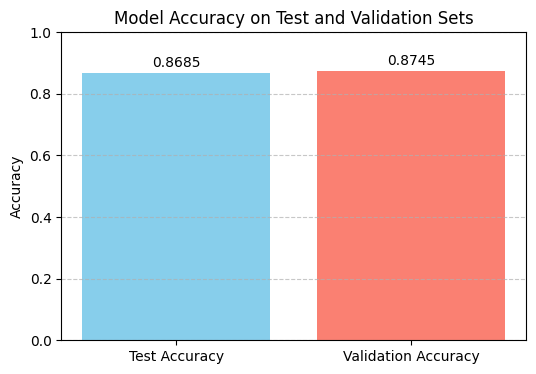

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


test_accuracy = accuracy_score(y_test, y_pred_test)
val_accuracy = accuracy_score(y_val, y_pred_val)

labels = ['Test Accuracy', 'Validation Accuracy']
scores = [test_accuracy, val_accuracy]


plt.figure(figsize=(6,4))
bars = plt.bar(labels, scores, color=['skyblue', 'salmon'])


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom')

plt.ylim(0, 1)
plt.title("Model Accuracy on Test and Validation Sets")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def predict_emotion(text):
    x = vectorizer.transform([text])
    pred = clf.predict(x)
    return le.inverse_transform(pred)[0]

print(predict_emotion("i feel kinda appalled that she feels like she needs to explain in wide and lenghth her body measures etc pp"))

anger


In [ ]:
from sklearn.naive_bayes import MultinomialNB

lnb = MultinomialNB()
lnb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred_test = lnb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

y_pred_val = lnb.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report on Validation Data:")
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Test Accuracy: 0.694
Classification Report on Test Data:
              precision    recall  f1-score   support

       anger       0.96      0.35      0.51       275
        fear       0.89      0.32      0.47       224
         joy       0.66      0.98      0.79       695
        love       1.00      0.06      0.12       159
     sadness       0.68      0.91      0.78       581
    surprise       0.00      0.00      0.00        66

    accuracy                           0.69      2000
   macro avg       0.70      0.44      0.44      2000
weighted avg       0.74      0.69      0.63      2000

Validation Accuracy: 0.681
Classification Report on Validation Data:
              precision    recall  f1-score   support

       anger       0.97      0.34      0.50       275
        fear       0.95      0.28      0.44       212
         joy       0.65      0.97      0.78       704
        love       1.00      0.07      0.13       178
     sadness       0.66      0.93      0.77       550
    su

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.svm import LinearSVC

svc = LinearSVC()
svc.fit(X_train, y_train)

LinearSVC()

In [ ]:
y_pred_test = svc.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

y_pred_val = svc.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report on Validation Data:")
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Test Accuracy: 0.8915
Classification Report on Test Data:
              precision    recall  f1-score   support

       anger       0.88      0.89      0.88       275
        fear       0.87      0.86      0.86       224
         joy       0.91      0.93      0.92       695
        love       0.78      0.78      0.78       159
     sadness       0.93      0.92      0.93       581
    surprise       0.76      0.68      0.72        66

    accuracy                           0.89      2000
   macro avg       0.85      0.84      0.85      2000
weighted avg       0.89      0.89      0.89      2000

Validation Accuracy: 0.899
Classification Report on Validation Data:
              precision    recall  f1-score   support

       anger       0.91      0.91      0.91       275
        fear       0.87      0.79      0.83       212
         joy       0.91      0.93      0.92       704
        love       0.85      0.83      0.84       178
     sadness       0.91      0.93      0.92       550
    s

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


val_report = classification_report(y_val, y_pred_val, target_names=le.classes_, output_dict=True)

In [ ]:
labels = list(le.classes_)
f1_scores = [val_report[label]['f1-score'] for label in labels]

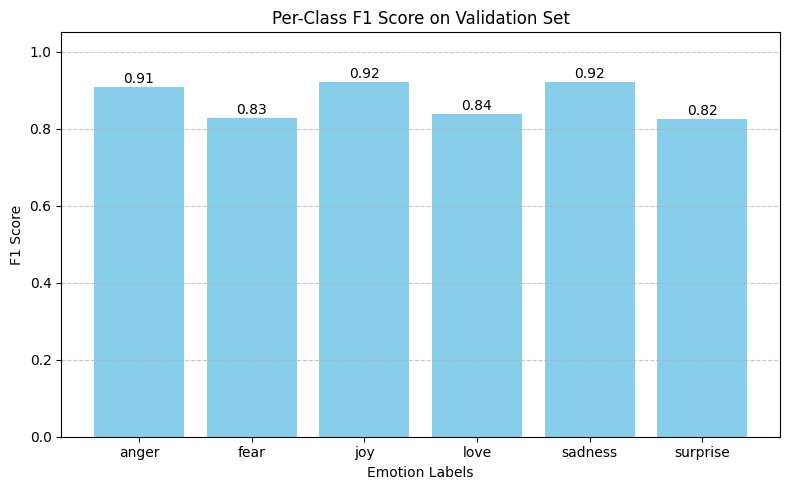

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, f1_scores, color='skyblue')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center')

plt.ylim(0, 1.05)
plt.title("Per-Class F1 Score on Validation Set")
plt.xlabel("Emotion Labels")
plt.ylabel("F1 Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_test = rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

y_pred_val = rf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report on Validation Data:")
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Test Accuracy: 0.8845
Classification Report on Test Data:
              precision    recall  f1-score   support

       anger       0.89      0.89      0.89       275
        fear       0.86      0.90      0.88       224
         joy       0.88      0.93      0.90       695
        love       0.78      0.70      0.74       159
     sadness       0.94      0.91      0.93       581
    surprise       0.72      0.58      0.64        66

    accuracy                           0.88      2000
   macro avg       0.84      0.82      0.83      2000
weighted avg       0.88      0.88      0.88      2000

Validation Accuracy: 0.8985
Classification Report on Validation Data:
              precision    recall  f1-score   support

       anger       0.92      0.88      0.90       275
        fear       0.85      0.88      0.87       212
         joy       0.90      0.93      0.91       704
        love       0.86      0.80      0.83       178
     sadness       0.92      0.92      0.92       550
    

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:13:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
y_pred_test = xgb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

y_pred_val = xgb.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report on Validation Data:")
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

Test Accuracy: 0.8855
Classification Report on Test Data:
              precision    recall  f1-score   support

       anger       0.90      0.89      0.90       275
        fear       0.89      0.88      0.89       224
         joy       0.88      0.91      0.90       695
        love       0.74      0.84      0.79       159
     sadness       0.96      0.89      0.92       581
    surprise       0.65      0.71      0.68        66

    accuracy                           0.89      2000
   macro avg       0.84      0.85      0.85      2000
weighted avg       0.89      0.89      0.89      2000

Validation Accuracy: 0.895
Classification Report on Validation Data:
              precision    recall  f1-score   support

       anger       0.93      0.89      0.91       275
        fear       0.84      0.83      0.84       212
         joy       0.89      0.93      0.91       704
        love       0.82      0.87      0.84       178
     sadness       0.94      0.89      0.92       550
    s

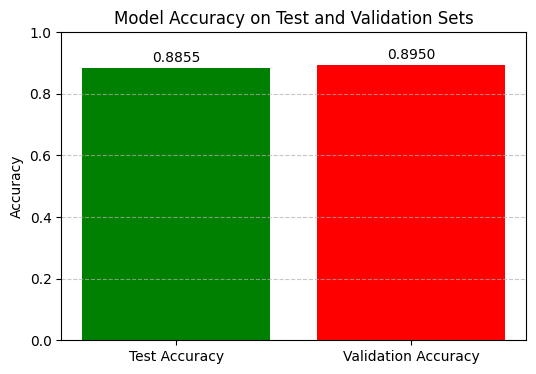

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


test_accuracy = accuracy_score(y_test, y_pred_test)
val_accuracy = accuracy_score(y_val, y_pred_val)

labels = ['Test Accuracy', 'Validation Accuracy']
scores = [test_accuracy, val_accuracy]


plt.figure(figsize=(6,4))
bars = plt.bar(labels, scores, color=['green', 'red'])


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom')

plt.ylim(0, 1)
plt.title("Model Accuracy on Test and Validation Sets")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


val_report1 = classification_report(y_val, y_pred_val, target_names=le.classes_, output_dict=True)

In [ ]:
labels = list(le.classes_)
f1_scores = [val_report1[label]['f1-score'] for label in labels]

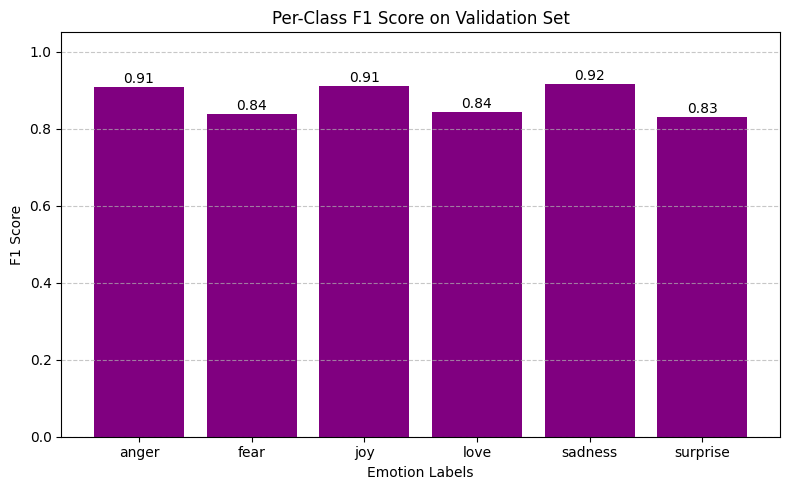

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, f1_scores, color='purple')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center')

plt.ylim(0, 1.05)
plt.title("Per-Class F1 Score on Validation Set")
plt.xlabel("Emotion Labels")
plt.ylabel("F1 Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def predict_emotion(text):
    x = vectorizer.transform([text])
    pred = xgb.predict(x)
    return le.inverse_transform(pred)[0]

print(predict_emotion("ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny"))

surprise
